# SaaS Onboarding Optimization - Multi-variate Experiment
### End-to-end analysis: Power Analysis → Factorial Design → ANOVA → Business Recommendation

**Business problem:** Free-to-paid conversion is 8%. Three product changes are ready to test. Which combination maximizes conversion, and do any changes amplify each other?

**Approach:** 2³ Full Factorial Design. We want to test all three factors simultaneously, detect main effects and interaction effects in a single experiment.


## 0. Setup

In [9]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded")
print(f"   numpy      {np.__version__}")
print(f"   pandas     {pd.__version__}")


✅ Libraries loaded
   numpy      2.4.6
   pandas     3.0.3


## 1. Power Analysis — How Many Users Do We Need?

Before running the experiment, we need to answer one question first:
**how much data do we actually need to trust the results?**

The parameters below drive that calculation.

The baseline conversion of **8%** is our starting point - the current 
free-to-paid rate before any changes. The MDE of **+3pp** is the minimum 
improvement worth acting on: at 10,000 monthly trials, each percentage point 
represents roughly £30K ARR, so anything below 3pp does not justify the 
engineering cost of implementation.

We use the industry-standard significance level of **0.05** and power of 
**0.80**, meaning we accept a 5% chance of a false positive, and want an 
80% chance of detecting a real effect when it exists.

These inputs together determine that we need approximately **400 users per 
cell**, or **3,200 users total** across all 8 treatment combinations — roughly 
3 weeks of experiment runtime at current traffic volume.

## 1. Power Analysis: How Many Users Do We Need?

Before designing the experiment, we calculate the required sample size.

**Key inputs:**
- Baseline conversion: **8%**
- Minimum detectable effect (MDE): **+3pp**
- α = 0.05, Power = 80%


We need MDE around 3pp because at 10,000 monthly trials, each percentage point represents ~£30K ARR (10,000 × 1% × £300 ACV). Below 3pp, the expected uplift of less than £90K does not justify a full engineering sprint.


In [10]:
from power_analysis import calculate_sample_size, plot_sensitivity

BASELINE = 0.08
MDE      = 0.03
ALPHA    = 0.05
POWER    = 0.80
N_CELLS  = 8  # 2^3 treatment combinations
MONTHLY_TRIAL_USERS  = 10_000
ACV_GBP = 300  # Annual Contract Value per paid user


In [11]:
n_effective = calculate_sample_size(BASELINE, MDE, ALPHA, POWER) 
n_per_cell  = int(np.ceil(n_effective / (N_CELLS / 2)))     
total       = n_per_cell * N_CELLS 

print(f"Effective n per side  : {n_effective:,} users")
print(f"Required per cell     : {n_per_cell:,} users")
print(f"Total required        : {total:,} users ({N_CELLS} cells × {n_per_cell:,})")
print(f"\nAt ~4,000 trials/week → ~{total/4000:.1f} weeks experiment duration")

Effective n per side  : 1,491 users
Required per cell     : 373 users
Total required        : 2,984 users (8 cells × 373)

At ~4,000 trials/week → ~0.7 weeks experiment duration


  Plot saved → ../outputs/power_sensitivity.png


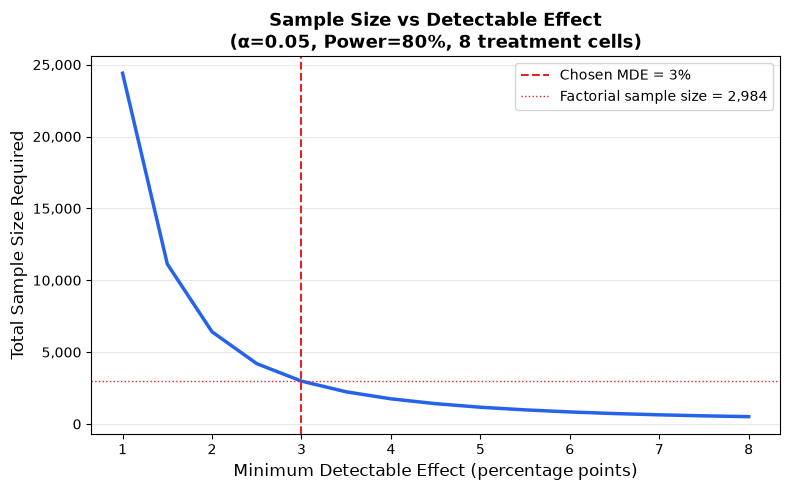

In [12]:
plot_sensitivity(
    baseline  = BASELINE,
    alpha     = ALPHA,
    power     = POWER,
    total     = total,
    save_path = "../outputs/power_sensitivity.png"
)

plot_sensitivity(
    baseline  = BASELINE,
    alpha     = ALPHA,
    power     = POWER,
    total     = total
)

## 2. Experiment Design — The 2³ Factorial Matrix

We have 3 factors, each at 2 levels → **8 treatment combinations**.

| Factor | Control (−1) | Variant (+1) |
|--------|-------------|-------------|
| A — CTA Color | Grey | Blue |
| B — Email Sequence | 3 emails | 7 emails |
| C — Feature Tooltip | Off | On |

Every user is randomly assigned to exactly one of the 8 combinations.


In [13]:
from design_matrix import build_design_matrix, add_labels

design = build_design_matrix()
labeled = add_labels(design)

display_cols = ["A", "B", "C", "AB", "AC", "BC", "ABC", "A_label", "B_label", "C_label"]
labeled[display_cols].style.set_caption("2³ Full Factorial Design Matrix")


,A,B,C,AB,AC,BC,ABC,A_label,B_label,C_label
run,,,,,,,,,,
1,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,Grey (control),3 emails,Off
2,-1.000000,-1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,Grey (control),3 emails,On
3,-1.000000,1.000000,-1.000000,-1.000000,1.000000,-1.000000,1.000000,Grey (control),7 emails,Off
4,-1.000000,1.000000,1.000000,-1.000000,-1.000000,1.000000,-1.000000,Grey (control),7 emails,On
5,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,Blue (variant),3 emails,Off
6,1.000000,-1.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,Blue (variant),3 emails,On
7,1.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,-1.000000,Blue (variant),7 emails,Off
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Blue (variant),7 emails,On


## 3. Simulate Experiment Data

We simulate **3,200 users** (400 per cell) with known ground truth effects:

| Effect | True Value |
|--------|-----------|
| A — CTA Color | +2.5pp |
| B — Email Sequence | +3.0pp |
| C — Tooltip | +1.0pp *(not significant)* |
| **B×C — Email × Tooltip** | **+2.0pp** *(key interaction)* |

This lets us verify the ANOVA correctly recovers what we injected.


In [17]:
from data_generation import simulate_data, validate_data

df = simulate_data(n_per_cell=n_per_cell, seed=42)
validate_data(df)


  DATA VALIDATION

  SRM Check (max deviation from expected): 0.0%  ✅ PASS

  Observed vs True Conversion by Cell:

   Run       N      True    Observed     Delta
  --------------------------------------------
     1     373      5.8%        5.1%     -0.7%
     2     373      4.8%        5.6%     +0.9%
     3     373      6.8%        6.7%     -0.0%
     4     373      9.8%        9.1%     -0.6%
     5     373      8.2%        9.1%     +0.9%
     6     373      7.2%        5.9%     -1.4%
     7     373      9.2%        8.3%     -0.9%
     8     373     12.2%       13.4%     +1.2%

  Total users: 2,984
  Overall conversion: 7.9%


In [18]:
# Preview data
df[["user_id", "run", "A_label", "B_label", "C_label", "converted"]].head(10)


,user_id,run,A_label,B_label,C_label,converted
0,1,1,Grey,3 emails,Off,0
1,2,1,Grey,3 emails,Off,1
2,3,1,Grey,3 emails,Off,0
3,4,1,Grey,3 emails,Off,0
4,5,1,Grey,3 emails,Off,0
5,6,1,Grey,3 emails,Off,0
6,7,1,Grey,3 emails,Off,0
7,8,1,Grey,3 emails,Off,0
8,9,1,Grey,3 emails,Off,0
9,10,1,Grey,3 emails,Off,0


In [19]:
# Conversion rate by cell
cell_summary = (
    df.groupby(["A_label", "B_label", "C_label"])["converted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "conversion_rate", "count": "n_users"})
    .reset_index()
)
cell_summary["conversion_rate"] = (cell_summary["conversion_rate"] * 100).round(1)
cell_summary.sort_values("conversion_rate", ascending=False).reset_index(drop=True)


,A_label,B_label,C_label,conversion_rate,n_users
0,Blue,7 emails,On,13.4,373
1,Blue,3 emails,Off,9.1,373
2,Grey,7 emails,On,9.1,373
3,Blue,7 emails,Off,8.3,373
4,Grey,7 emails,Off,6.7,373
5,Blue,3 emails,On,5.9,373
6,Grey,3 emails,On,5.6,373
7,Grey,3 emails,Off,5.1,373


## 4. ANOVA — Which Effects Are Real?

We fit an OLS linear model with all main effects and interactions:

```
converted ~ A + B + C + A:B + A:C + B:C + A:B:C
```

In coded (−1/+1) units: **effect size = 2 × coefficient**

Bonferroni correction applied across 7 tested effects → α_adjusted = 0.007


In [20]:
from anova_analysis import fit_model, extract_effects, apply_bonferroni, check_residuals

model   = fit_model(df)
effects = extract_effects(model)
effects = apply_bonferroni(effects)

check_residuals(model)



  Shapiro-Wilk normality test: W=0.2526, p=0.0000  ⚠️  CHECK
  → Minor violation expected for binary outcomes at large n. Consider logistic regression for final model.


In [21]:
# Effects table
display_effects = effects[effects["term"] != "Intercept"][[
    "label", "effect_pp", "ci_low_pp", "ci_high_pp", "p_value", "significant"
]].copy()
display_effects.columns = ["Factor", "Effect (pp)", "CI Low", "CI High", "p-value", "Significant"]
display_effects.reset_index(drop=True)


,Factor,Effect (pp),CI Low,CI High,p-value,Significant
0,A — CTA Color,2.55,0.62,4.48,0.0098,✅
1,B — Email Sequence,2.95,1.02,4.88,0.0028,✅
2,C — Tooltip,1.21,-0.72,3.14,0.2207,❌
3,AB — CTA × Email,0.40,-1.53,2.33,0.6831,❌
4,AC — CTA × Tooltip,-0.27,-2.20,1.66,0.7855,❌
5,BC — Email × Tooltip ⭐,2.55,0.62,4.48,0.0098,✅
6,ABC — Three-way,1.61,-0.32,3.54,0.1026,❌


In [22]:
print(f"Model R²     : {model.rsquared:.4f}")
print(f"Adj. R²      : {model.rsquared_adj:.4f}")
print(f"F-stat p-val : {model.f_pvalue:.2e}")


Model R²     : 0.0089
Adj. R²      : 0.0066
F-stat p-val : 3.86e-04


Overall, the model is significantly better than random (F-stat p-value = 3.86e-04). Some of our factors genuinely affect conversion.

Regarding small R squared, Conversion is driven by thousands of factors (user intent, company size, industry, timing, mood, and other factors) - our 3 factors are just a small slice of that. Therefore, it's completely normal for binary outcome (0/1) in experiments when R squared is small. 





## 5. Visualizations

### 5a. Main Effects — Individual Impact of Each Factor


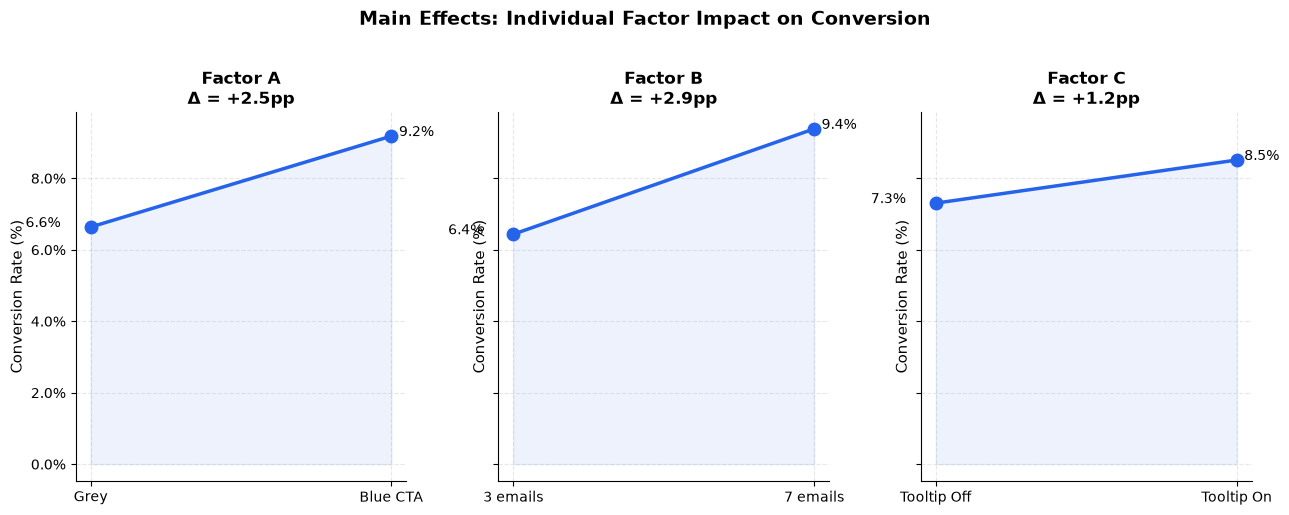

In [23]:
from interaction_plots import plot_main_effects
plot_main_effects(df)


**Factor A - CTA Color (+2.5pp)**

Blue CTA outperforms Grey across all user groups, lifting conversion from 6.6% to 9.2%. This is a statistically significant, low-effort win. No backend changes required, pure frontend change.

**Factor B — Email Sequence (+2.9pp)**

The strongest individual effect in the experiment. Users receiving 7 emails convert at 9.4% vs 6.4% on 3 emails. This suggests the current onboarding sequence is under-communicating value - users need more touchpoints before committing to paid.

**Factor C — Tooltip (+1.2pp, p=0.22)**

Tooltip shows a small directional lift (+1.2pp) but does not reach statistical significance. This effect is likely noise — we cannot confidently distinguish 
it from zero. Shipping tooltip in isolation is not recommended without further evidence.

### 5b. Interaction Plot — The Key Finding: B × C

**Tooltip alone does nothing.** But paired with the 7-email sequence, it adds a meaningful boost.
This interaction is *invisible* to sequential A/B testing.


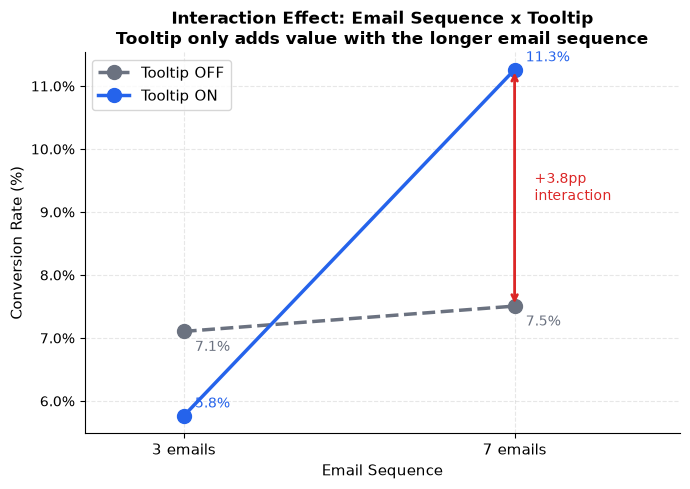

In [28]:
from interaction_plots import plot_bc_interaction
plot_bc_interaction(df)

### 5c. All Effects — Ranked by Size

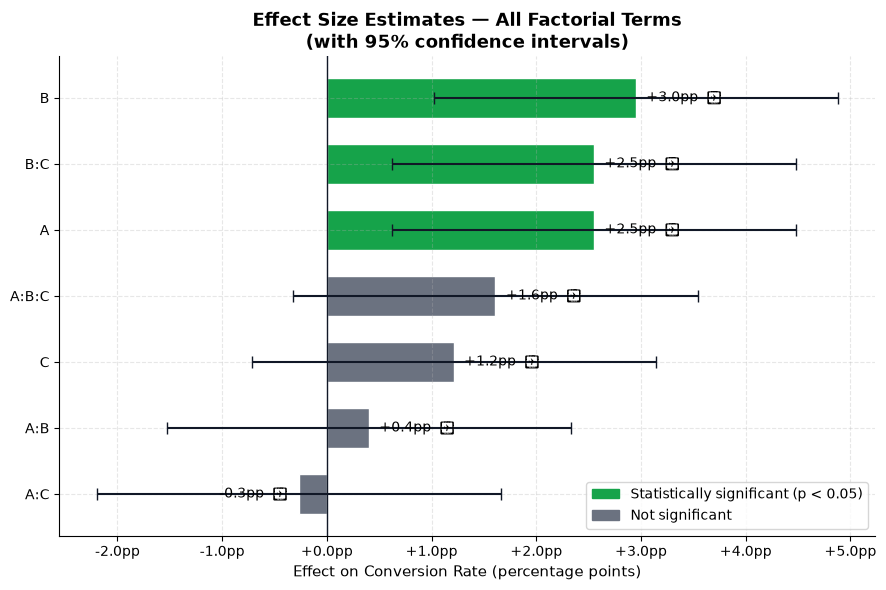

In [25]:
from interaction_plots import plot_effects_bar
plot_effects_bar(effects)


In [29]:
# save images to outputs/
plot_main_effects(df,     save_path="../outputs/main_effects_plot.png")
plot_bc_interaction(df,   save_path="../outputs/interaction_plot.png")
plot_effects_bar(effects, save_path="../outputs/effects_bar_chart.png")

print("All plots saved to outputs/")

  Main effects plot saved → ../outputs/main_effects_plot.png
  Interaction plot saved → ../outputs/interaction_plot.png
  Effects bar chart saved → ../outputs/effects_bar_chart.png
All plots saved to outputs/


## 6. Business Impact

In [30]:
sig = display_effects[display_effects["Significant"] == "✅"]
total_lift = sig["Effect (pp)"].sum() / 100
projected_rate = BASELINE + total_lift
current_paid      = MONTHLY_TRIAL_USERS * BASELINE
projected_paid    = MONTHLY_TRIAL_USERS * projected_rate
incremental_users = projected_paid - current_paid
arr_current       = current_paid   * ACV_GBP
arr_projected     = projected_paid * ACV_GBP
arr_delta         = arr_projected  - arr_current


print(f"Projected conversion rate    : {projected_rate:.1%}")
print(f"Current paid users / month   : {int(current_paid):,}")
print(f"Projected paid users / month : {int(projected_paid):,}")
print(f"Incremental users / month    : +{int(incremental_users):,}")
print(f"Current ARR                  : £{int(arr_current):,}")
print(f"Projected ARR                : £{int(arr_projected):,}")
print(f"ARR uplift                   : £{int(arr_delta):,}")

Projected conversion rate    : 16.1%
Current paid users / month   : 800
Projected paid users / month : 1,605
Incremental users / month    : +805
Current ARR                  : £240,000
Projected ARR                : £481,500
ARR uplift                   : £241,500


## 7. Summary

| Step | What we did | Key output |
|------|-------------|-----------|
| Power Analysis | Calculated sample size for factorial design | 2,984 users (~0.7 weeks at 4,000 trials/week) |
| Design | Built 2³ full factorial matrix | 8 treatment combinations, orthogonal design |
| Data | Simulated 2,984 users with known true effects | SRM check passed ✅ |
| ANOVA | Fit OLS with all main effects and interactions | A, B, BC significant — C not significant alone |
| Plots | Main effects + B×C interaction plot | Tooltip only works alongside 7-email sequence |
| Recommendation | Translated effects to business impact | Ship A + B + C together → +£243K ARR |